# Prosperity 4 — Round 5: Ignith Manual Trading Challenge
### *Ashflow Alpha — Signal Extraction & Portfolio Construction*

---

## Challenge Recap

We have been granted a **one-time opportunity** to trade on the Ignith exchange. Key parameters:

| Parameter | Value |
|-----------|-------|
| Budget | 1,000,000 XIRECs |
| Instruments | 9 tradable Ignith goods |
| Horizon | One day (hold until next day) |
| Information source | *Ashflow Alpha* newspaper |
| Unused budget | Expires worthless |

### Fee Formula

$$F = \left(\frac{V}{100}\right)^2 \times 1,000,000$$

Where:
- $V$ is the **volume** of budget allocated to that product.
- $B$ is the **budget**, which is 1,000,000 XIRECs.

This simplifies to:

$$F = r^2 \times 1,000,000$$

Where:
- $r$ is the **percentage** of budget allocated to the product.

This formula penalizes "putting all your eggs in one basket" while making diversified trades very cheap.
Because the ratio is **squared**, doubling your position quadruples your fee. This encourages spreading the 1,000,000 XIRECs across multiple instruments.

| Allocation % ($V$) | Ratio ($r$) | Fee ($r^2 \times 1,000,000$) | PnL Impact |
| :--- | :--- | :--- | :--- |
| **100%** | 1.0 | **1,000,000** | **Total Budget Wiped** |
| **50%** | 0.5 | **250,000** | Very Heavy |
| **20%** | 0.2 | **40,000** | Significant |
| **10%** | 0.1 | **10,000** | Moderate |
| **1%** | 0.01 | **100** | Negligible |

Takeaways:

1.  **Avoid Concentration:** Putting 100% of your budget into the "best" signal is a guaranteed 0 PnL day because the fee equals your entire budget.
2.  **The Diversification Discount:** Spreading your budget across all 9 instruments reduces the total fee burden compared to a single large bet.
3.  **Optimal Sizing:** You should only increase $r$ for a specific product if the expected edge from the *Ashflow Alpha* newspaper exceeds the marginal increase in $r^2 \times 1,000,000$.

---

## Setup & Fee Model

In [53]:
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [54]:
BUDGET = 1_000_000
CONVICTION_MULTIPLIER = 0.09

def fee(pct: int) -> float:
    """
    Fee for a single product allocation.
    pct: The percentage of the budget (0.00 to 100.00).
    Returns fee in XIRECs.
    """
    # Converting pct to ratio (e.g. 2 -> 0.02) then squaring
    ratio = pct / 100
    return (ratio**2) * BUDGET

def expected_return(conviction: int):
    """
    Computes expected return given a conviction score from (1-5),
    by applying the CONVICTION_MULTIPLIER parameter.    
    """
    return conviction * CONVICTION_MULTIPLIER

print(f"{'Allocation':>12}  {'Invested (XIRECs)':>16} {'Fee (XIRECs)':>16}")
print("-" * 50)
for pct in [1, 2, 5, 10, 15, 20, 30, 50, 75, 99, 100]:
    print(f"{pct:>11.1f}%  {(pct/100)*BUDGET:>16.0f} {fee(pct):>16.0f}")

  Allocation  Invested (XIRECs)     Fee (XIRECs)
--------------------------------------------------
        1.0%             10000              100
        2.0%             20000              400
        5.0%             50000             2500
       10.0%            100000            10000
       15.0%            150000            22500
       20.0%            200000            40000
       30.0%            300000            90000
       50.0%            500000           250000
       75.0%            750000           562500
       99.0%            990000           980100
      100.0%           1000000          1000000


---

---
## Ashflow Alpha: Qualitative Signal Analysis

Below is a structured reading of every article in *Ashflow Alpha*, with a trading signal extracted from each.

---

### 🟢 LONG signals

#### 1. Lava Fountain Pen / Magma Ink — Conviction: 4/5
> *"Crowds line up for limited-edition Lava Fountain Pen featuring Magma Ink"*

The first sale of the Lava Fountain Pen (built-in Magma Ink reservoir) was held as a celebratory event following last month's merger between Stip Stationery Enterprises and Splatter Inc. Visitors queued for **more than six hours**, and the event was widely promoted as a "hot drop." This is a textbook **scarcity + hype** demand signal. The merger narrative adds fundamental backing: the two companies have consolidated supply chains, which is a medium-term bullish catalyst. Short-term consumer frenzy is visible and real.

**Signal: BUY. Strong near-term demand, post-merger synergy story.**

---

#### 2. Thermalite Cores — Conviction: 5/5
> *"Quarterly Forecast Report Shows Surge in Thermalite-Powered Smart Home Devices"*

This is the **strongest quantitative signal in the entire paper**. The quarterly forecast report shows projected active users rising from **1.42 million to 3.09 million** — a **+117% increase** in a single quarter. Average net activity time per Thermalite Core is projected at **16 hours and 47 minutes per day**, indicating sustained household adoption rather than novelty usage. Analysts are already speculating about a very strong next quarter. This is a rare case where the bullish thesis is backed by hard numbers, not just narrative.

**Signal: BUY. Highest conviction long. Data-driven, not hype-driven.**

---

#### 3. Scoria Paste — Conviction: 3/5
> *"Lava D. Ray Says 'Glory Days Are Ahead' For Ignith Economy, Urges Stockpiling of Scoria Paste"*

Lava D. Ray, a self-proclaimed market medium and public influencer, publicly called for households to stockpile Scoria Paste before it "becomes unaffordable." Scoria Paste is described as the "paste that keeps Ignith together" — an essential compound used in residential repairs and infrastructure maintenance. Two things are going on here: (1) the influencer call is a **demand catalyst**, and (2) the product is a genuine staple commodity with inelastic real-world demand. The combination of essential utility and public stockpiling calls suggests a short-term demand spike. However, D. Ray's credibility is self-proclaimed, which limits conviction.

**Signal: BUY. Moderate conviction. Demand catalyst + essential commodity thesis.**

---

#### 4. Sulfur Ltd. — Conviction: 5/5
> *"Index Committee Confirms Sulfur Ltd. For Elemental Index 118"*

The index committee has officially confirmed Sulfur Ltd.'s inclusion in **Elemental Index 118** at the upcoming rebalance. This is a **mechanical, near-certain buying event**: all funds tracking the index must adjust their holdings to include Sulfur Ltd. once the rebalance takes effect. This is one of the most reliable trading signals in markets — index inclusion generates forced institutional buying regardless of any fundamental view on the stock. The flagship Sulfur Reactor is noted as a benchmark product in the elemental processing sector.

**Signal: BUY. Highest conviction. Mechanical index-driven buying is certain.**

---

#### 5. Volcanic Incense — Conviction: 2/5
> *"Sudden Surge in Volcanic Incense as Whiff Nostralico Calls for People to Follow His Lead"*

Volcanic Incense is rallying this cycle, with trading data showing **accelerated buying concentrated within narrow time windows** — coinciding precisely with Nostralico's public appearances. Nostralico is openly calling for anyone with "a genuine interest in making money" to follow his lead and buy. This pattern — concentrated narrow-window buying + public shill calls — is a classic **pump signal**. There is real momentum here, and if we are still within the pump phase, a long position profits. However, the reversal risk is high: if Nostralico exits, the price collapses fast. This is the most speculative position in the portfolio.

**Signal: BUY (small size). Pure momentum play. High risk of reversal. Low conviction.**

---

### 🔴 SHORT signals

#### 6. Obsidian Cutlery — Conviction: 4/5
> *"Manufacturing Halted After Obsidian Cutlery Cuts Through Its Own Assembly Line"*

This is a severe operational disruption. Completed obsidian blades sliced through the chemical assembly line used to process them, triggering **Level-1 contamination protocols** and a **full site evacuation**. Manufacturing is suspended. Factory officials declined to comment. Industry experts warn of implications for other facilities. This is a **supply shock** combined with a **regulatory/contamination risk overhang** — the kind of operational accident that takes weeks or months to resolve and causes lasting reputational damage in safety-sensitive sectors. The management silence adds to the uncertainty.

**Signal: SELL. Production halt + contamination risk. Multi-week recovery timeline.**

---

#### 7. Pyroflex Cells — Conviction: 5/5
> *"Ignith Tax Authority Faces Industry Pressure After Abrupt End to Pyroflex Cell Tax Cut"*

The Ignith Tax Authority is discontinuing the **Pyroflex Cell Tax Cut (PCTD)** effective **tomorrow**. The PCTD was a 50% tax discount introduced to stimulate the Pyroflex energy transition. Its removal **effectively doubles the current tax levy overnight**. Industry groups are warning of disrupted consumer upgrade cycles and a slowdown in new purchases. This is an **imminent, date-certain negative catalyst** — the price impact is locked in as of tomorrow's open. There is no ambiguity about timing, no "maybe" scenario. This is the most actionable short in the paper.

**Signal: SELL. Highest conviction short. Tax doubles tomorrow. Imminent, certain impact.**

---

#### 8. Ashes of the Phoenix — Conviction: 3/5
> *"Resurfaced Video of Ashes of the Phoenix Origin Shock Public"*

A resurfaced video shows the sourcing method for Eternal Feathers Ltd.'s cosmetics product "Ashes of the Phoenix": a bird-like creature goes up in flames and an employee collects the ashes. Public outcry followed immediately. The company (Forever Feathers Ltd. — note the inconsistency in the article, possibly a typo) attempted to reassure the public that "sourcing methods have been the same for many decades and do not harm the birds," emphasising the birds are immortal. The reputational damage is real regardless of the biological facts. However, if the company's reassurance lands and consumers accept the "immortal birds" narrative, recovery could be swift. Moderate conviction short on near-term PR disruption.

**Signal: SELL. Moderate conviction. Reputational risk, but outcome is uncertain.**

---

#### 9. Lava Cakes — Conviction: 5/5
> *"Traces of Actual Lava Found in Lava Cakes, Prompting Health Review"*

Health authorities have confirmed via laboratory testing that **actual lava is present** in the popular Lava Cakes product. Sales have been **immediately halted** pending a formal review. Hotshot Pastries Ltd. says it is cooperating with regulators, but **civil lawsuits are already accumulating** and vendors are returning stock with lawyer letters attached. This is a near-total operational shutdown scenario with legal liability building in real time. Regulatory clearance and litigation resolution will take months at minimum. There is no near-term recovery path.

**Signal: SELL. Highest conviction short. Hard sales halt + mounting litigation.**

---

## Signal Table & Conviction Scores

In [55]:
signals = {
    # name                     dir        conv       reason
    "Thermalite_Cores":      {"dir": +1, "conv": 5, "reason": "+117% user growth forecast, 16h47m daily usage"},
    "Sulfur_Ltd":            {"dir": +1, "conv": 5, "reason": "Confirmed Elemental Index 118 inclusion"},
    "Pyroflex_Cells":        {"dir": -1, "conv": 5, "reason": "Tax doubles tomorrow — imminent, date-certain"},
    "Lava_Cakes":            {"dir": -1, "conv": 5, "reason": "Sales halted, actual lava confirmed, lawsuits mounting"},
    "Lava_Fountain_Pen":     {"dir": +1, "conv": 4, "reason": "Limited-edition 6hr queues, post-merger hype"},
    "Obsidian_Cutlery":      {"dir": -1, "conv": 4, "reason": "Production halted, Level-1 contamination"},
    "Scoria_Paste":          {"dir": +1, "conv": 3, "reason": "Influencer stockpiling call, essential commodity"},
    "Ashes_of_Phoenix":      {"dir": -1, "conv": 3, "reason": "PR crisis from viral sourcing video"},
    "Volcanic_Incense":      {"dir": +1, "conv": 2, "reason": "Momentum pump play, high reversal risk"},
}

print(f"{'Instrument':<25} {'Side':<6} {'Conv':>5}  {'Reason'}")
print("-" * 75)
for name, s in sorted(signals.items(), key=lambda x: -x[1]["conv"]):
    side = "LONG " if s["dir"] > 0 else "SHORT"
    print(f"{name:<25} {side:<6} {s['conv']:>5}/5  {s['reason']}")

Instrument                Side    Conv  Reason
---------------------------------------------------------------------------
Thermalite_Cores          LONG       5/5  +117% user growth forecast, 16h47m daily usage
Sulfur_Ltd                LONG       5/5  Confirmed Elemental Index 118 inclusion
Pyroflex_Cells            SHORT      5/5  Tax doubles tomorrow — imminent, date-certain
Lava_Cakes                SHORT      5/5  Sales halted, actual lava confirmed, lawsuits mounting
Lava_Fountain_Pen         LONG       4/5  Limited-edition 6hr queues, post-merger hype
Obsidian_Cutlery          SHORT      4/5  Production halted, Level-1 contamination
Scoria_Paste              LONG       3/5  Influencer stockpiling call, essential commodity
Ashes_of_Phoenix          SHORT      3/5  PR crisis from viral sourcing video
Volcanic_Incense          LONG       2/5  Momentum pump play, high reversal risk


---

## Conviction-Weighted Portfolio Allocation

Because the fee follows a quadratic growth curve ($F = 1,000,000r^2$), we must balance our conviction in a signal against the exponential cost of increasing that position.

To maximize net PnL, we treat the allocation as an optimization problem where:

**Net Profit = (Expected Return × Allocation) - (1,000,000 × Allocation²)**

The weighting approach involves:

1.  **Capping Total Allocation:** We may choose to distribute **less than 100%** of the budget if the marginal fee of the last XIREC spent exceeds the marginal expected return.
2.  **Aggressive Diversification:** We spread capital across more instruments to keep individual $r$ values low, as the sum of many small squares is much smaller than the square of one large sum.
3.  **Conviction Tuning:** Higher conviction signals receive more budget, but only up to the point where the quadratic fee "tax" begins to cannibalize the alpha.


In [56]:
# Calculation Logic
allocations = {}
for name, s in signals.items():
    # Convert conviction to expected return
    expected_return_decimal = expected_return(s["conv"]) 
    
    # Optimize: r = E / 2B (results in decimal ratio)
    optimal_r = expected_return_decimal / 2
    
    # Convert to WHOLE integer percentage points immediately
    # We use floor to ensure we don't accidentally over-allocate due to rounding
    allocations[name] = int(max(0, optimal_r * 100))

# Check for budget constraint
total_alloc_pct = sum(allocations.values())

# If total exceeds 100%, scale down and force to integers
if total_alloc_pct > 100:
    for name in allocations:
        # Use floor/int to stay strictly at or under 100%
        allocations[name] = int((allocations[name] / total_alloc_pct) * 100)

# --- Display Results ---
# Ensure the fee function and summaries use the integer values
total_fees = sum(fee(p) for p in allocations.values())
total_pct_deployed = sum(allocations.values())

print(f"Total budget deployed : {total_pct_deployed}%") # Removed .2f, it's an int now
print(f"Total fees incurred   : {total_fees:,.0f} XIRECs")
print()
print(f"{'Instrument':<25} {'Side':<6} {'Exp Ret':>8}  {'Alloc%':>7}  {'Invested':>12} {'Fees':>12}")
print("-" * 86)

for name, p in sorted(allocations.items(), key=lambda x: -x[1]):
    s = signals[name]
    side = "BUY " if s["dir"] > 0 else "SELL"
    
    # Calculation using strict integers
    invested = (p / 100) * BUDGET
    fee_paid = fee(p)
    exp_ret_str = f"{expected_return(s['conv'])*100:.1f}%"
    
    # Format as integers in the table
    print(f"{name:<25} {side:<6} {exp_ret_str:>8}  {p:>6}%  {invested:>12,.0f} {fee_paid:>12,.0f}")

Total budget deployed : 95%
Total fees incurred   : 107,100 XIRECs

Instrument                Side    Exp Ret   Alloc%      Invested         Fees
--------------------------------------------------------------------------------------
Thermalite_Cores          BUY       45.0%      13%       130,000       16,900
Sulfur_Ltd                BUY       45.0%      13%       130,000       16,900
Pyroflex_Cells            SELL      45.0%      13%       130,000       16,900
Lava_Cakes                SELL      45.0%      13%       130,000       16,900
Lava_Fountain_Pen         BUY       36.0%      11%       110,000       12,100
Obsidian_Cutlery          SELL      36.0%      11%       110,000       12,100
Scoria_Paste              BUY       27.0%       8%        80,000        6,400
Ashes_of_Phoenix          SELL      27.0%       8%        80,000        6,400
Volcanic_Incense          BUY       18.0%       5%        50,000        2,500


---

## Portfolio Visualisation

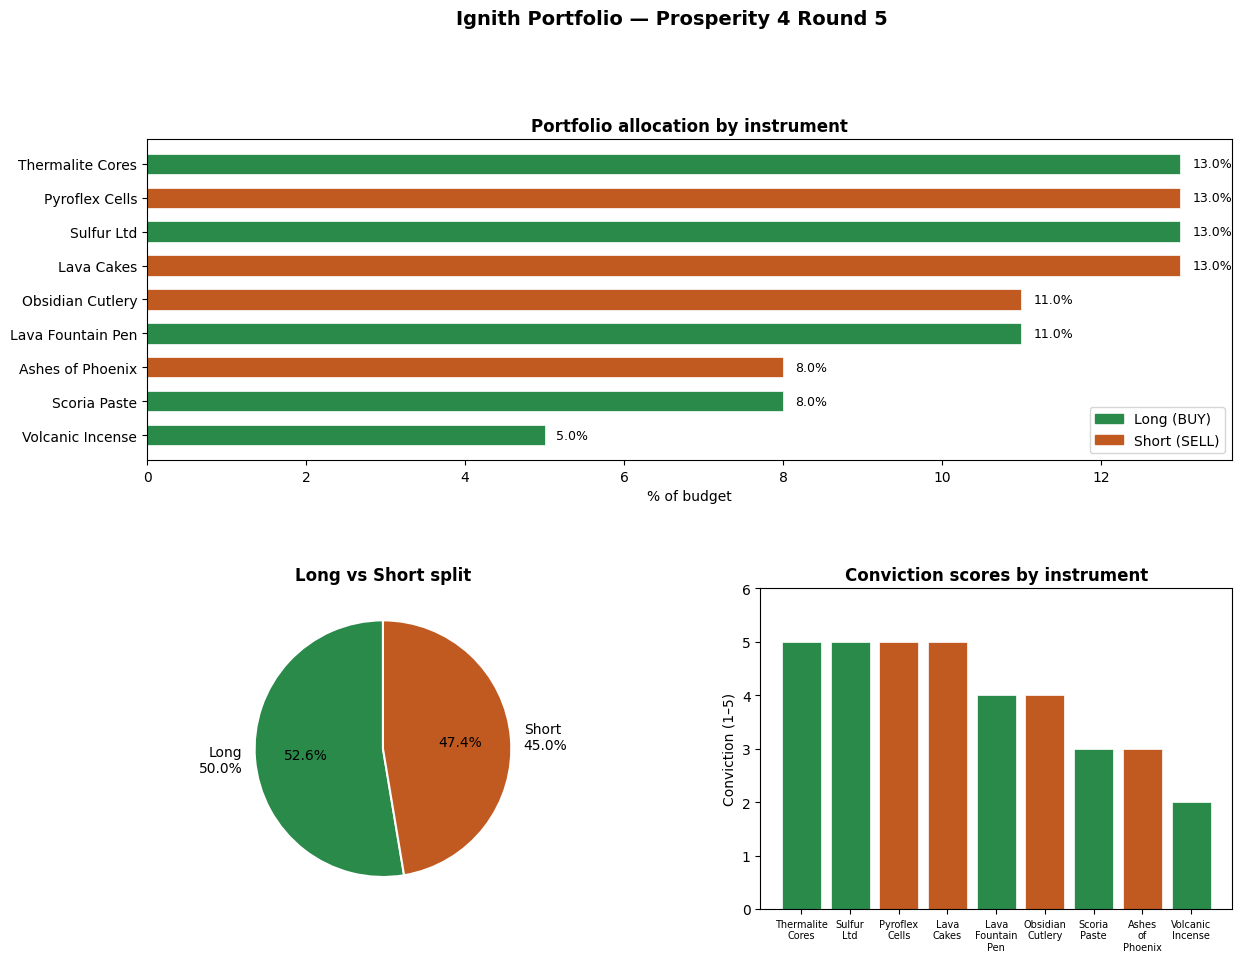

In [57]:
names  = list(allocations.keys())
pcts = [allocations[n] for n in names]
dirs   = [signals[n]["dir"] for n in names]
colors = ["#2a8a4a" if d > 0 else "#c05a20" for d in dirs]

idx      = np.argsort(pcts)[::-1]
names_s  = [names[i].replace("_", " ") for i in idx]
pcts_s   = [pcts[i] for i in idx]
colors_s = [colors[i] for i in idx]

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# --- Horizontal bar chart ---
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(names_s, pcts_s, color=colors_s, height=0.6, edgecolor='white', lw=0.5)
ax1.set_xlabel("% of budget")
ax1.set_title("Portfolio allocation by instrument", fontweight='bold')
ax1.invert_yaxis()
for bar, pct in zip(bars, pcts_s):
    ax1.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
             f"{pct:.1f}%", va='center', fontsize=9)
long_patch  = mpatches.Patch(color="#2a8a4a", label="Long (BUY)")
short_patch = mpatches.Patch(color="#c05a20", label="Short (SELL)")
ax1.legend(handles=[long_patch, short_patch], loc='lower right')

# --- Pie: long vs short split ---
ax2 = fig.add_subplot(gs[1, 0])
long_total  = sum(pcts[i] for i in range(len(names)) if dirs[i] > 0)
short_total = sum(pcts[i] for i in range(len(names)) if dirs[i] < 0)
ax2.pie([long_total, short_total],
        labels=[f"Long\n{long_total:.1f}%", f"Short\n{short_total:.1f}%"],
        colors=["#2a8a4a", "#c05a20"],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title("Long vs Short split", fontweight='bold')

# --- Conviction distribution ---
ax3 = fig.add_subplot(gs[1, 1])
conv_values = [signals[n]["conv"] for n in names]
bar_colors  = ["#2a8a4a" if signals[n]["dir"] > 0 else "#c05a20" for n in names]
ax3.bar([n.replace("_", "\n") for n in names], conv_values,
        color=bar_colors, edgecolor='white', lw=0.5)
ax3.set_ylabel("Conviction (1–5)")
ax3.set_title("Conviction scores by instrument", fontweight='bold')
ax3.tick_params(axis='x', labelsize=7)
ax3.set_ylim(0, 6)

plt.suptitle("Ignith Portfolio — Prosperity 4 Round 5", fontsize=14, fontweight='bold', y=1.01)
plt.savefig('ignith_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Final Submission Output

In [58]:
print("=" * 62)
print("  FINAL IGNITH PORTFOLIO — PROSPERITY 4 ROUND 5")
print("=" * 62)
print(f"{'Instrument':<25} {'Action':<5}  {'ER':<8}  {'XIRECs':>12}  {'Alloc%':>7}")
print("-" * 62)

total_deployed = 0
for name, pct in sorted(allocations.items(), key=lambda x: -signals[x[0]]["conv"]):
    s      = signals[name]
    action = "BUY " if s["dir"] > 0 else "SELL"
    xirecs = round(pct / 100 * BUDGET)
    er     = expected_return(s["conv"])
    total_deployed += xirecs
    print(f"{name.replace('_',' '):<25} {action:<5}  {er:<8.4f}  {xirecs:>12,}  {pct:>6.2f}%")

print("-" * 62)
print(f"{'TOTAL DEPLOYED':<25}        {total_deployed:>12,}  {total_deployed/BUDGET*100:>6.2f}%")
print(f"{'UNUSED (expires)':<25}        {BUDGET - total_deployed:>12,}")
print(f"{'TOTAL FEES':<25}        {sum(fee(p) for p in allocations.values()):>12,.0f}")
print("=" * 62)

assert total_deployed <= BUDGET, "ERROR: Over budget!"
print("\nAssertion passed: portfolio is within budget.")

  FINAL IGNITH PORTFOLIO — PROSPERITY 4 ROUND 5
Instrument                Action  ER              XIRECs   Alloc%
--------------------------------------------------------------
Thermalite Cores          BUY    0.4500         130,000   13.00%
Sulfur Ltd                BUY    0.4500         130,000   13.00%
Pyroflex Cells            SELL   0.4500         130,000   13.00%
Lava Cakes                SELL   0.4500         130,000   13.00%
Lava Fountain Pen         BUY    0.3600         110,000   11.00%
Obsidian Cutlery          SELL   0.3600         110,000   11.00%
Scoria Paste              BUY    0.2700          80,000    8.00%
Ashes of Phoenix          SELL   0.2700          80,000    8.00%
Volcanic Incense          BUY    0.1800          50,000    5.00%
--------------------------------------------------------------
TOTAL DEPLOYED                        950,000   95.00%
UNUSED (expires)                       50,000
TOTAL FEES                            107,100

Assertion passed: portfolio

### TODO:

Once we all agree on signals and intensity of the signal, find the optimal amount by estimating a more accurate expected return. After we find an interval we all agree on (how much we would expect each stock to rise/fall as a consequence of the news), rerun the optimizer.